# Applied Exercise 6 - Wage Data: Polynomial Regression and Step Functions

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from sklearn.preprocessing import SplineTransformer
from sklearn.pipeline import make_pipeline
from ISLP import load_data
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from statsmodels.stats.anova import anova_lm
from statsmodels.formula.api import ols
from pygam import LinearGAM, s
from sklearn.preprocessing import PolynomialFeatures, SplineTransformer
from ISLP.models import poly, bs

import warnings
warnings.filterwarnings("ignore")

In [2]:
Wage = load_data("Wage")
X = Wage[["age"]]
y = Wage["wage"]

print("=" * 60)
print("WAGE DATA")
print("=" * 60)
print("Observations:", len(Wage))

WAGE DATA
Observations: 3000



POLYNOMIAL REGRESSION
 Degree      CV_MSE
      1 1677.205121
      2 1601.356479
      3 1596.246418
      4 1595.074236
      5 1595.071099
      6 1594.868498
      7 1593.864488
      8 1593.448852
      9 1596.119186
     10 1603.719084

Best polynomial degree = 8


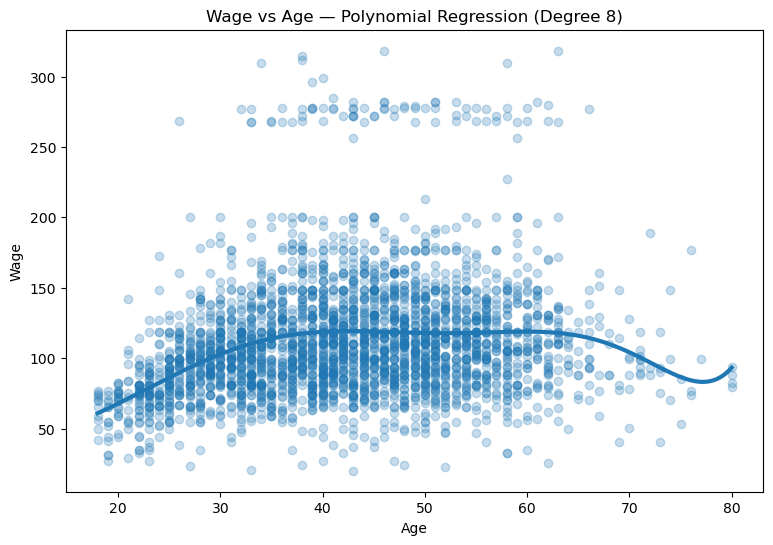

In [3]:
print("\n" + "=" * 60)
print("POLYNOMIAL REGRESSION")
print("=" * 60)

kf = KFold(n_splits=10, shuffle=True, random_state=1)
poly_results = []
for degree in range(1, 11):
    model = Pipeline([("poly", PolynomialFeatures(degree=degree, include_bias=False)), ("lr", LinearRegression())])
    mse = -cross_val_score(model, X, y, cv=kf, scoring="neg_mean_squared_error").mean()
    poly_results.append([degree, mse])

poly_results = pd.DataFrame(poly_results, columns=["Degree", "CV_MSE"])
best_degree = int(poly_results.loc[poly_results["CV_MSE"].idxmin(), "Degree"])

print(poly_results.to_string(index=False))
print(f"\nBest polynomial degree = {best_degree}")

poly_model = Pipeline([("poly", PolynomialFeatures(degree=best_degree, include_bias=False)), ("lr", LinearRegression())])
poly_model.fit(X, y)

age_grid = np.linspace(X["age"].min(), X["age"].max(), 500).reshape(-1, 1)
wage_pred = poly_model.predict(age_grid)

plt.figure(figsize=(9, 6))
plt.scatter(Wage["age"], Wage["wage"], alpha=0.25)
plt.plot(age_grid, wage_pred, linewidth=3)
plt.xlabel("Age")
plt.ylabel("Wage")
plt.title(f"Wage vs Age — Polynomial Regression (Degree {best_degree})")
plt.show()

In [4]:
print("\n" + "=" * 60)
print("ANOVA COMPARISON")
print("=" * 60)

anova_models = []
for degree in range(1, 6):
    X_poly = np.column_stack([X["age"] ** i for i in range(1, degree + 1)])
    X_poly = sm.add_constant(X_poly)
    anova_models.append(sm.OLS(y, X_poly).fit())

anova_table = anova_lm(*anova_models)
print(anova_table)


ANOVA COMPARISON
   df_resid           ssr  df_diff        ss_diff           F        Pr(>F)
0    2998.0  5.022216e+06      0.0            NaN         NaN           NaN
1    2997.0  4.793430e+06      1.0  228786.010128  143.593107  2.363850e-32
2    2996.0  4.777674e+06      1.0   15755.693664    9.888756  1.679202e-03
3    2995.0  4.771604e+06      1.0    6070.152124    3.809813  5.104620e-02
4    2994.0  4.770322e+06      1.0    1282.563017    0.804976  3.696820e-01


- Polynomial regression models of degrees 1 through 10 and used 10-fold cross-validation to select the degree. Cross-validation selected a polynomial of degree 8, which had the lowest CV MSE of 1593.45. However, the improvement after degree 3 was very small. The CV MSE decreased from 1596.25 for degree 3 to 1593.45 for degree 8.
- The ANOVA results provide a somewhat different conclusion. The quadratic and cubic terms were statistically significant, with p-values of approximately 2.36 × 10^-32 and 0.00168, respectively. The fourth-degree term had a p-value of approximately 0.051 (borderline at 95% CI), while the fifth-degree term was not significant (p ≈ 0.370).
- Thus, ANOVA suggests that a cubic model may be sufficient, whereas cross-validation selected degree 8. This difference occurs because ANOVA tests statistical significance of additional terms, whereas cross-validation evaluates predictive performance.


STEP FUNCTION
 Number_of_Cuts      CV_MSE
              2 1732.217912
              3 1683.428414
              4 1636.091836
              5 1631.093416
              6 1623.889511
              7 1612.766774
              8 1602.143809
              9 1610.918506
             10 1606.639281

Best number of cuts = 8


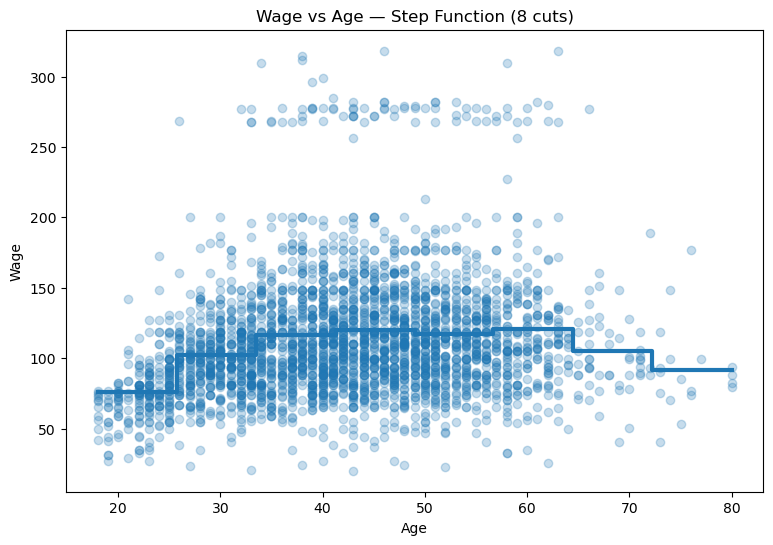

In [5]:
class StepFunction(BaseEstimator, TransformerMixin):
    def __init__(self, n_cuts=5):
        self.n_cuts = n_cuts

    def fit(self, X, y=None):
        x = np.asarray(X).ravel()
        self.bins_ = np.linspace(x.min(), x.max(), self.n_cuts + 1)
        return self

    def transform(self, X):
        x = np.asarray(X).ravel()
        groups = np.digitize(x, self.bins_[1:-1])
        return np.eye(self.n_cuts)[groups]

print("\n" + "=" * 60)
print("STEP FUNCTION")
print("=" * 60)

step_results = []
for cuts in range(2, 11):
    model = Pipeline([("step", StepFunction(n_cuts=cuts)), ("lr", LinearRegression())])
    mse = -cross_val_score(model, X, y, cv=kf, scoring="neg_mean_squared_error").mean()
    step_results.append([cuts, mse])

step_results = pd.DataFrame(step_results, columns=["Number_of_Cuts", "CV_MSE"])
best_cuts = int(step_results.loc[step_results["CV_MSE"].idxmin(), "Number_of_Cuts"])

print(step_results.to_string(index=False))
print(f"\nBest number of cuts = {best_cuts}")

step_model = Pipeline([("step", StepFunction(n_cuts=best_cuts)), ("lr", LinearRegression())])
step_model.fit(X, y)

age_grid_flat = np.linspace(X["age"].min(), X["age"].max(), 500)
step_pred = step_model.predict(age_grid_flat.reshape(-1, 1))

plt.figure(figsize=(9, 6))
plt.scatter(Wage["age"], Wage["wage"], alpha=0.25)
plt.plot(age_grid_flat, step_pred, linewidth=3, drawstyle="steps-mid")
plt.xlabel("Age")
plt.ylabel("Wage")
plt.title(f"Wage vs Age — Step Function ({best_cuts} cuts)")
plt.show()

- Step-function models using between 2 and 10 cuts and used 10-fold cross-validation to select the optimal number of cuts which is 8. Cross-validation selected a step function with 8 cuts, which produced the lowest CV MSE of approximately 1602.14.
- The CV error decreased as the number of cuts increased from 2 to 8, but increased again when using 9 or 10 cuts. This suggests that using too few cuts does not capture enough of the relationship between age and wage, while additional cuts beyond 8 provide little benefit and may begin to overfit the data.
- The step-function model had a slightly higher CV MSE than the best polynomial model, suggesting that the polynomial regression provides somewhat better predictive performance for wage based on age.

# Applied Exercise 7 - Exploring Other Predictors in the Wage Data

WAGE DATA — SELECTED PREDICTORS
         wage        education            maritl        jobclass  \
0   75.043154     1. < HS Grad  1. Never Married   1. Industrial   
1   70.476020  4. College Grad  1. Never Married  2. Information   
2  130.982177  3. Some College        2. Married   1. Industrial   
3  154.685293  4. College Grad        2. Married  2. Information   
4   75.043154       2. HS Grad       4. Divorced  2. Information   

           health health_ins  
0       1. <=Good      2. No  
1  2. >=Very Good      2. No  
2       1. <=Good     1. Yes  
3  2. >=Very Good     1. Yes  
4       1. <=Good     1. Yes  


<Figure size 900x500 with 0 Axes>

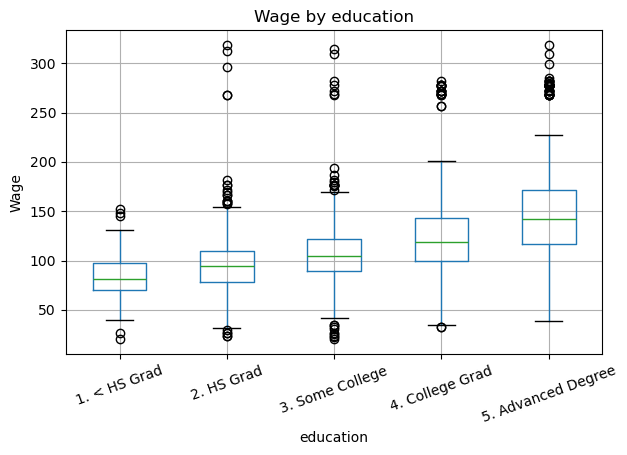

<Figure size 900x500 with 0 Axes>

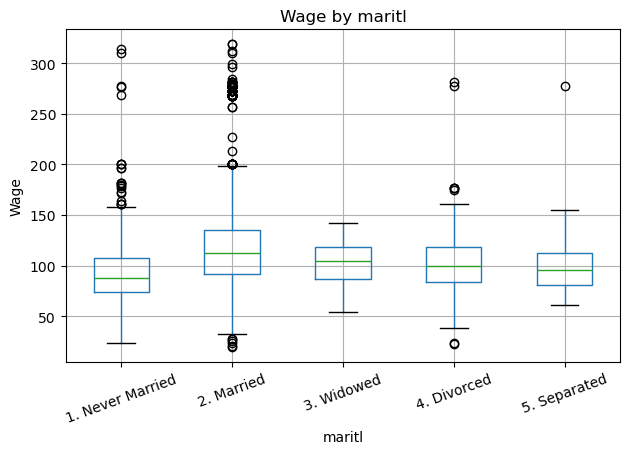

<Figure size 900x500 with 0 Axes>

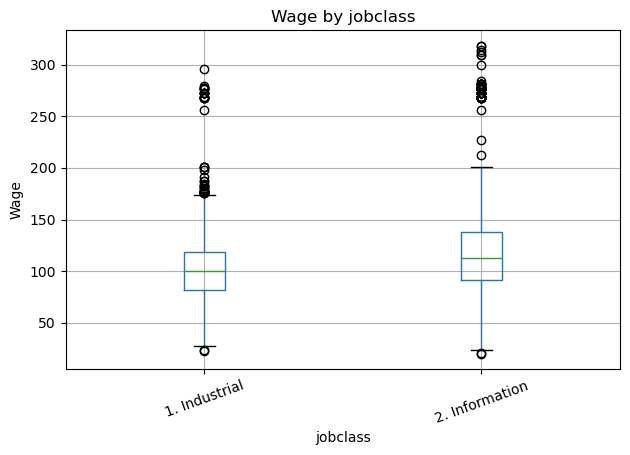

<Figure size 900x500 with 0 Axes>

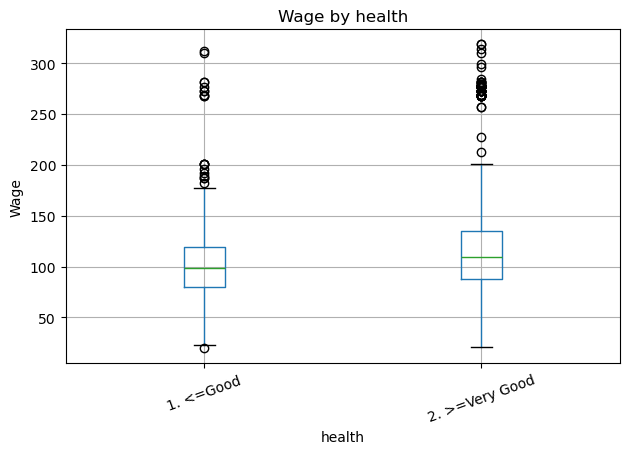

<Figure size 900x500 with 0 Axes>

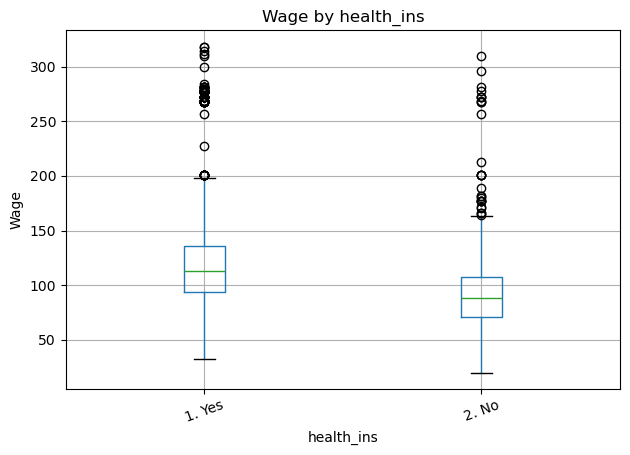

In [6]:
Wage = load_data("Wage")

print("=" * 60)
print("WAGE DATA — SELECTED PREDICTORS")
print("=" * 60)
print(Wage[['wage', 'education', 'maritl', 'jobclass', 'health', 'health_ins']].head())

categorical_vars = ['education', 'maritl', 'jobclass', 'health', 'health_ins']
for var in categorical_vars:
    plt.figure(figsize=(9, 5))
    Wage.boxplot(column='wage', by=var)
    plt.title(f'Wage by {var}')
    plt.suptitle('')
    plt.xlabel(var)
    plt.ylabel('Wage')
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

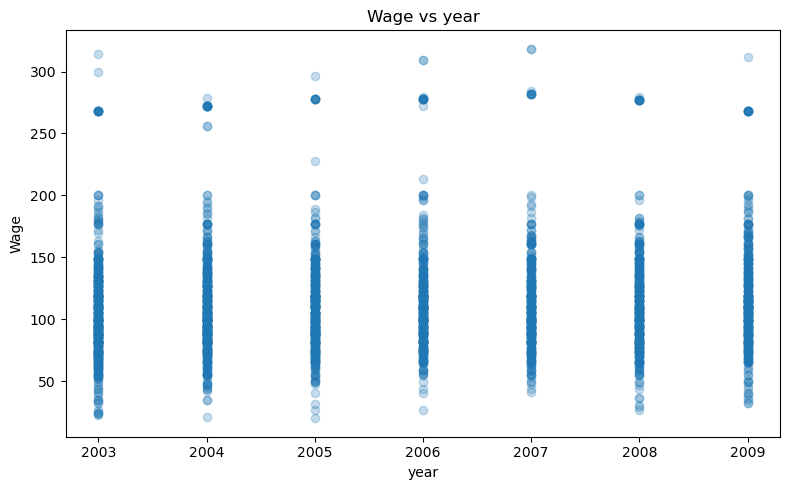

In [7]:
continuous_vars = ['year']
for var in continuous_vars:
    plt.figure(figsize=(8, 5))
    plt.scatter(Wage[var], Wage['wage'], alpha=0.25)
    plt.xlabel(var)
    plt.ylabel('Wage')
    plt.title(f'Wage vs {var}')
    plt.tight_layout()
    plt.show()

POLYNOMIAL REGRESSION — AGE
   Degree  Adjusted_R2           AIC
0       1     0.037953  30786.674044
1       2     0.081473  30648.798920
2       3     0.084186  30640.921874
3       4     0.085044  30639.107877
4       5     0.084985  30640.301396


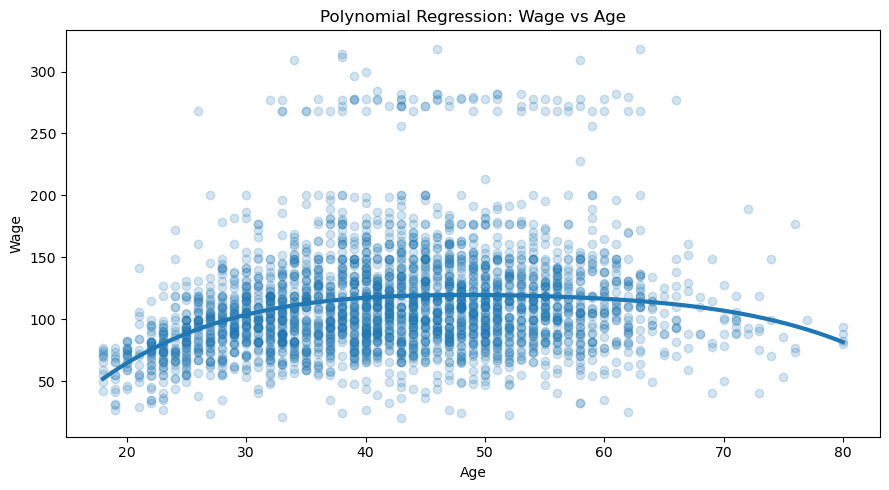

In [8]:
print("=" * 60)
print("POLYNOMIAL REGRESSION — AGE")
print("=" * 60)

degrees = [1, 2, 3, 4, 5]
poly_results = []

for d in degrees:
    X = np.column_stack([Wage['age'] ** i for i in range(1, d + 1)])
    X = sm.add_constant(X)
    model = sm.OLS(Wage['wage'], X).fit()
    poly_results.append([d, model.rsquared_adj, model.aic])

poly_results = pd.DataFrame(poly_results, columns=['Degree', 'Adjusted_R2', 'AIC'])
print(poly_results)

X_age = np.column_stack([Wage['age'] ** i for i in range(1, 5)])
X_age = sm.add_constant(X_age)
age_model = sm.OLS(Wage['wage'], X_age).fit()

age_grid = np.linspace(Wage['age'].min(), Wage['age'].max(), 300)
X_grid = np.column_stack([age_grid ** i for i in range(1, 5)])
X_grid = sm.add_constant(X_grid)
age_pred = age_model.predict(X_grid)

plt.figure(figsize=(9, 5))
plt.scatter(Wage['age'], Wage['wage'], alpha=0.2)
plt.plot(age_grid, age_pred, linewidth=3)
plt.xlabel('Age')
plt.ylabel('Wage')
plt.title('Polynomial Regression: Wage vs Age')
plt.tight_layout()
plt.show()

SPLINE REGRESSION — AGE


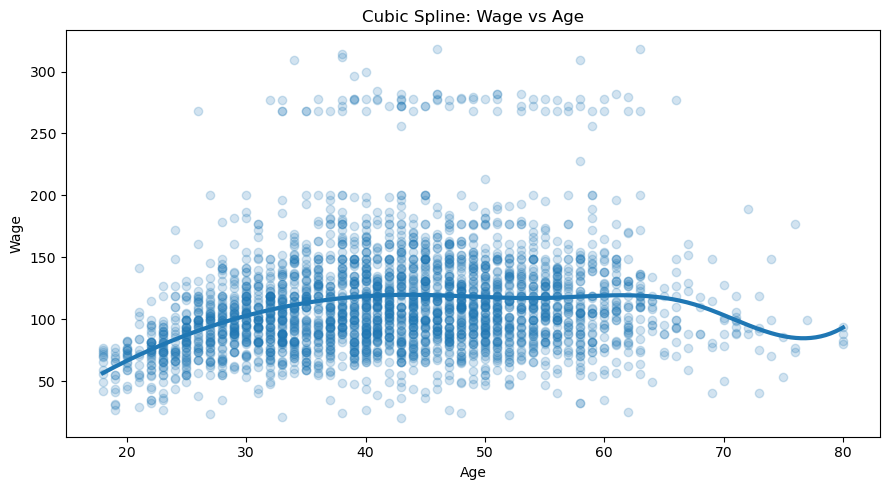

In [9]:
print("=" * 60)
print("SPLINE REGRESSION — AGE")
print("=" * 60)

X = Wage[['age']]
y = Wage['wage']

spline_model = make_pipeline(SplineTransformer(n_knots=6, degree=3), LinearRegression())
spline_model.fit(X, y)

age_pred_spline = spline_model.predict(pd.DataFrame({'age': age_grid}))

plt.figure(figsize=(9, 5))
plt.scatter(Wage['age'], Wage['wage'], alpha=0.2)
plt.plot(age_grid, age_pred_spline, linewidth=3)
plt.xlabel('Age')
plt.ylabel('Wage')
plt.title('Cubic Spline: Wage vs Age')
plt.tight_layout()
plt.show()

WAGE BY JOB CLASS
                      mean      median        std  count
jobclass                                                
1. Industrial   103.321129   99.689464  35.110674   1544
2. Information  120.592721  112.648896  46.131439   1456


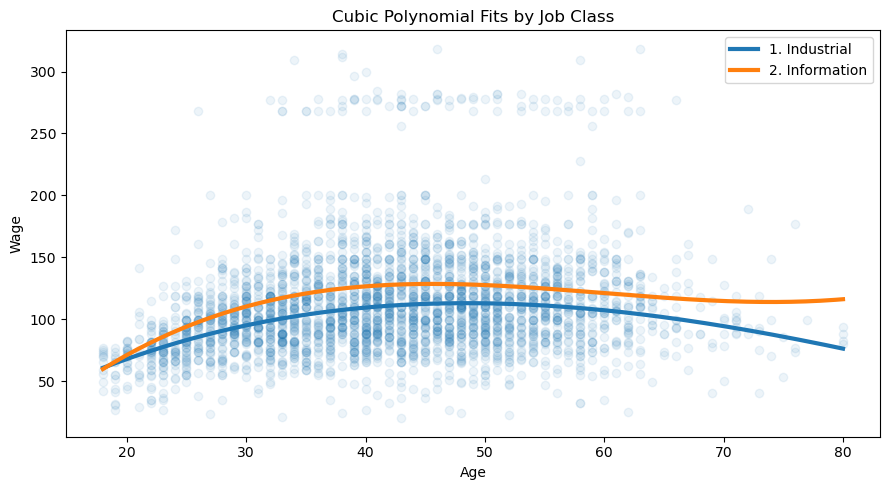

In [10]:
print("=" * 60)
print("WAGE BY JOB CLASS")
print("=" * 60)

print(Wage.groupby('jobclass')['wage'].agg(['mean', 'median', 'std', 'count']))
plt.figure(figsize=(9, 5))

for group in Wage['jobclass'].unique():
    subset = Wage[Wage['jobclass'] == group]
    X = np.column_stack([subset['age'] ** i for i in range(1, 4)])
    X = sm.add_constant(X)
    model = sm.OLS(subset['wage'], X).fit()

    grid = np.linspace(subset['age'].min(), subset['age'].max(), 200)
    X_grid = np.column_stack([grid ** i for i in range(1, 4)])
    X_grid = sm.add_constant(X_grid)

    plt.plot(grid, model.predict(X_grid), linewidth=3, label=group)

plt.scatter(Wage['age'], Wage['wage'], alpha=0.08)
plt.xlabel('Age')
plt.ylabel('Wage')
plt.title('Cubic Polynomial Fits by Job Class')
plt.legend()
plt.tight_layout()
plt.show()

- The exploratory analysis shows that wage is associated with several predictors besides age.
- Education, job class, health status and health insurance show visible differences in wage distributions across their categories.
- The relationship between age and wage is clearly non-linear, so a flexible polynomial or spline model provides a better representation than a simple linear relationship.
- Job class also appears to be associated with wage, and the relationship between age and wage can differ across job classes.
- Overall, the results suggest that wage is influenced by both categorical and continuous predictors, and flexible non-linear models can capture patterns that a simple linear model may miss.

# Applied Exercise 8 - Non-Linear Models on the Auto Data Set

In [11]:
Auto = load_data("Auto")
Auto = Auto.drop(columns=["Unnamed: 0"], errors="ignore")
predictors = ["cylinders", "displacement", "horsepower", "weight", "acceleration", "year", "origin"]

In [12]:
results = []
for x in predictors:
    data = Auto[[x, "mpg"]].dropna()
    linear = ols(f"mpg ~ {x}", data=data).fit()
    quadratic = ols(f"mpg ~ {x} + I({x}**2)", data=data).fit()
    cubic = ols(f"mpg ~ {x} + I({x}**2) + I({x}**3)", data=data).fit()
    results.append([x, linear.rsquared_adj, quadratic.rsquared_adj, cubic.rsquared_adj])

results = pd.DataFrame(results, columns=["Predictor", "Linear Adj R2", "Quadratic Adj R2", "Cubic Adj R2"])

print("=" * 60)
print("POLYNOMIAL REGRESSION RESULTS")
print("=" * 60)
print(results.to_string(index=False))

print("\n" + "=" * 60)
print("BEST POLYNOMIAL MODELS")
print("=" * 60)
for x in predictors:
    data = Auto[[x, "mpg"]].dropna()
    models = {d: ols("mpg ~ " + " + ".join([x] + [f"I({x}**{j})" for j in range(2, d + 1)]), data=data).fit() for d in [1, 2, 3]}
    best_d = max(models, key=lambda d: models[d].rsquared_adj)
    print(f"{x}: degree {best_d}, adjusted R² = {models[best_d].rsquared_adj:.4f}")

POLYNOMIAL REGRESSION RESULTS
   Predictor  Linear Adj R2  Quadratic Adj R2  Cubic Adj R2
   cylinders       0.603675          0.605434      0.638491
displacement       0.647327          0.687209      0.687246
  horsepower       0.604938          0.685953      0.685803
      weight       0.691842          0.713683      0.712947
acceleration       0.177102          0.189820      0.189288
        year       0.335328          0.364274      0.363833
      origin       0.317716          0.328413      0.328413

BEST POLYNOMIAL MODELS
cylinders: degree 3, adjusted R² = 0.6385
displacement: degree 3, adjusted R² = 0.6872
horsepower: degree 2, adjusted R² = 0.6860
weight: degree 2, adjusted R² = 0.7137
acceleration: degree 2, adjusted R² = 0.1898
year: degree 2, adjusted R² = 0.3643
origin: degree 2, adjusted R² = 0.3284


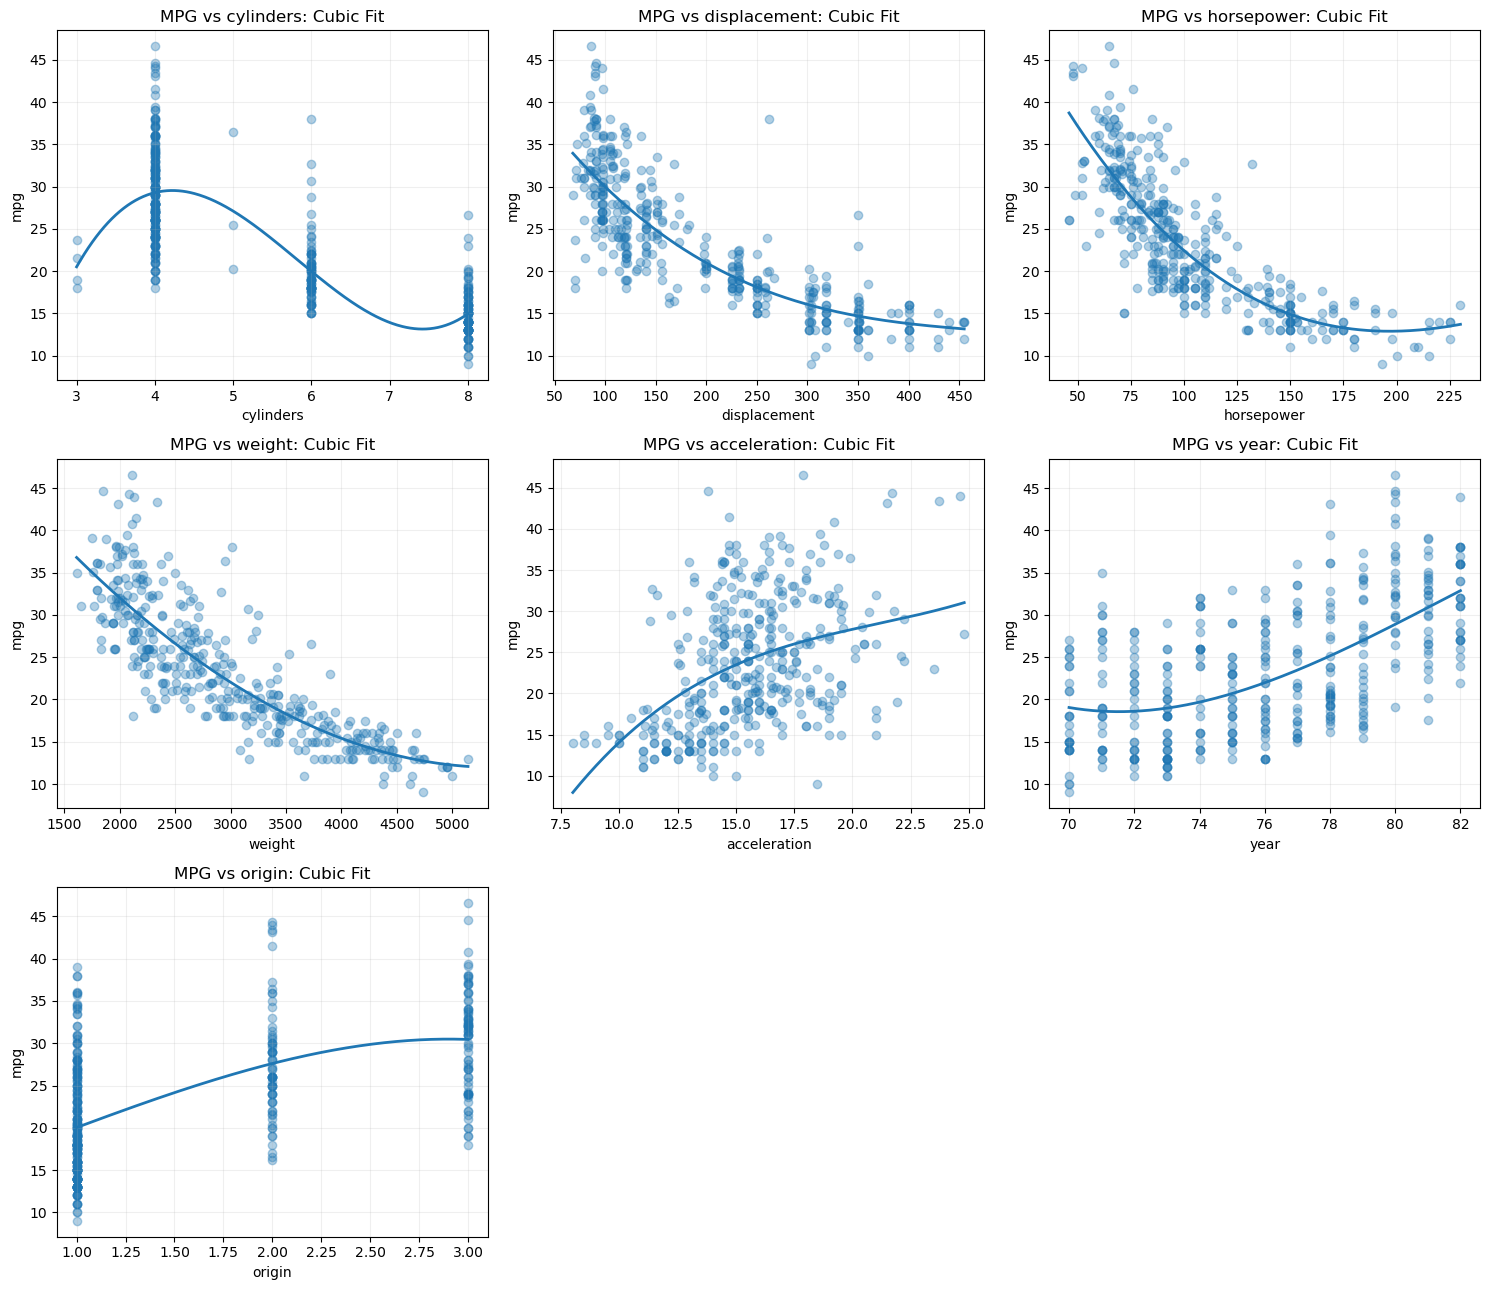

In [13]:
fig, axes = plt.subplots(3, 3, figsize=(15, 13))
axes = axes.ravel()

for i, x in enumerate(predictors):
    data = Auto[[x, "mpg"]].dropna()
    model = ols(f"mpg ~ {x} + I({x}**2) + I({x}**3)", data=data).fit()
    grid = np.linspace(data[x].min(), data[x].max(), 300)
    pred = model.predict(pd.DataFrame({x: grid}))
    axes[i].scatter(data[x], data["mpg"], alpha=0.35)
    axes[i].plot(grid, pred, linewidth=2)
    axes[i].set_xlabel(x)
    axes[i].set_ylabel("mpg")
    axes[i].set_title(f"MPG vs {x}: Cubic Fit")
    axes[i].grid(alpha=0.2)

for j in range(len(predictors), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

- The polynomial models show that several predictors have clear non-linear relationships with mpg. In particular, displacement, horsepower, weight,
and year show substantial departures from a simple linear relationship.
- The polynomial regression results and fitted curves indicate that adding quadratic and/or cubic terms can improve the fit for several predictors.
- The scatterplots also provide visual evidence of these departures from linearity.

# Applied Exercise 9 - Polynomial Regression and Regression Splines

In [2]:
Boston = load_data("Boston")
X = Boston["dis"].values.reshape(-1, 1)
y = Boston["nox"].values
grid = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
kf = KFold(n_splits=10, shuffle=True, random_state=1)

CUBIC POLYNOMIAL REGRESSION
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.715
Model:                            OLS   Adj. R-squared:                  0.713
Method:                 Least Squares   F-statistic:                     419.3
Date:                Mon, 17 Aug 2026   Prob (F-statistic):          2.71e-136
Time:                        21:48:06   Log-Likelihood:                 690.44
No. Observations:                 506   AIC:                            -1373.
Df Residuals:                     502   BIC:                            -1356.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.9341   

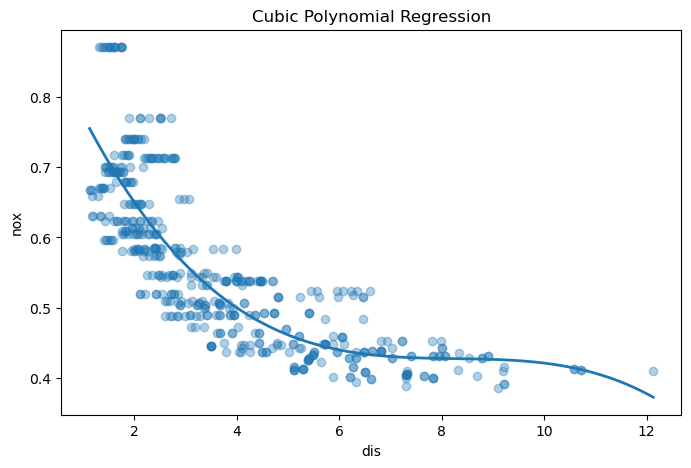

In [3]:
print("=" * 60)
print("CUBIC POLYNOMIAL REGRESSION")
print("=" * 60)

poly3 = PolynomialFeatures(degree=3, include_bias=False)
X3 = poly3.fit_transform(X)
cubic_model = sm.OLS(y, sm.add_constant(X3)).fit()
print(cubic_model.summary())

grid3 = poly3.transform(grid)
pred3 = cubic_model.predict(sm.add_constant(grid3))

plt.figure(figsize=(8, 5))
plt.scatter(X, y, alpha=0.35)
plt.plot(grid, pred3, linewidth=2)
plt.xlabel("dis")
plt.ylabel("nox")
plt.title("Cubic Polynomial Regression")
plt.show()

All three polynomial terms were statistically significant (p < 0.001), providing strong evidence of a non-linear relationship between `dis` and `nox`. The fitted relationship is clearly non-linear, as shown in the plot.

POLYNOMIAL REGRESSION: DEGREES 1-10
 Degree      RSS
      1 2.768563
      2 2.035262
      3 1.934107
      4 1.932981
      5 1.915290
      6 1.878257
      7 1.849484
      8 1.835630
      9 1.833331
     10 1.838305


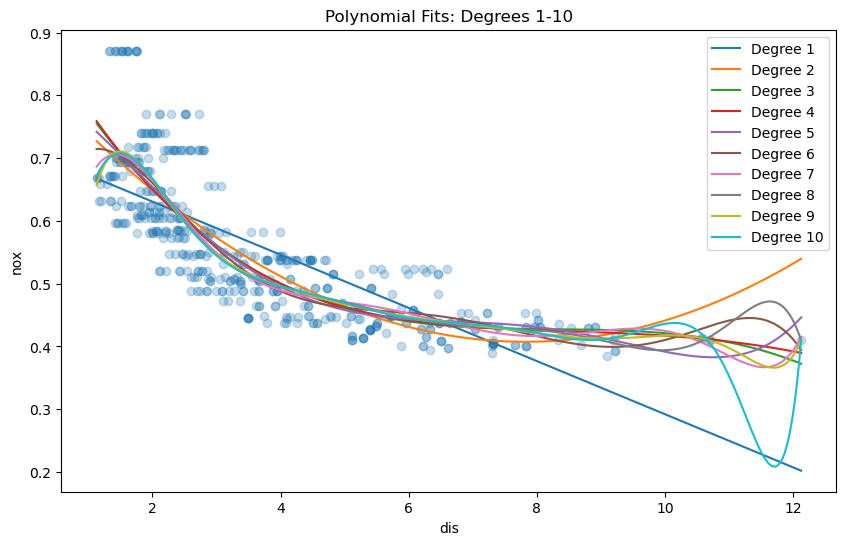

In [4]:
print("=" * 60)
print("POLYNOMIAL REGRESSION: DEGREES 1-10")
print("=" * 60)

rss_results = []
plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.25)

for d in range(1, 11):
    pf = PolynomialFeatures(degree=d, include_bias=False)
    Xd = pf.fit_transform(X)
    model = LinearRegression().fit(Xd, y)
    rss = np.sum((y - model.predict(Xd)) ** 2)
    rss_results.append([d, rss])
    pred = model.predict(pf.transform(grid))
    plt.plot(grid, pred, label=f"Degree {d}")

rss_df = pd.DataFrame(rss_results, columns=["Degree", "RSS"])
print(rss_df.to_string(index=False))

plt.xlabel("dis")
plt.ylabel("nox")
plt.title("Polynomial Fits: Degrees 1-10")
plt.legend()
plt.show()

After degree 3, the reduction in RSS becomes relatively small. The lowest training RSS occurs around degree 9, but training RSS alone is not an appropriate criterion for selecting the polynomial degree because increasingly complex models can overfit the data.

CROSS-VALIDATION
 Degree   CV_MSE
      1 0.005505
      2 0.004066
      3 0.003870
      4 0.003879
      5 0.004090
      6 0.005066
      7 0.011997
      8 0.005829
      9 0.008859
     10 0.004951

Best polynomial degree = 3


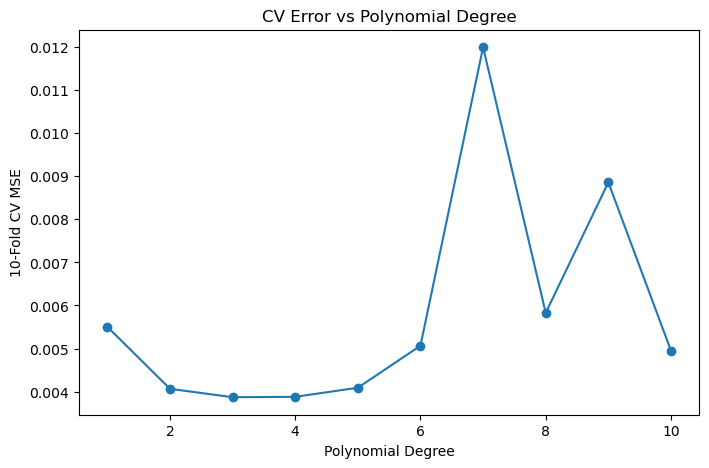

In [5]:
print("=" * 60)
print("CROSS-VALIDATION")
print("=" * 60)

cv_results = []
for d in range(1, 11):
    model = make_pipeline(PolynomialFeatures(degree=d, include_bias=False), LinearRegression())
    mse = -cross_val_score(model, X, y, cv=kf, scoring="neg_mean_squared_error").mean()
    cv_results.append([d, mse])

cv_df = pd.DataFrame(cv_results, columns=["Degree", "CV_MSE"])
print(cv_df.to_string(index=False))
best_degree = int(cv_df.loc[cv_df["CV_MSE"].idxmin(), "Degree"])
print(f"\nBest polynomial degree = {best_degree}")

plt.figure(figsize=(8, 5))
plt.plot(cv_df["Degree"], cv_df["CV_MSE"], marker="o")
plt.xlabel("Polynomial Degree")
plt.ylabel("10-Fold CV MSE")
plt.title("CV Error vs Polynomial Degree")
plt.show()

The model achieved an R-squared of approximately 0.715. The fitted spline captures the strong non-linear relationship between `dis` and `nox`. The knots were determined automatically by the spline transformation rather than being manually specified.

REGRESSION SPLINE — 4 DF
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.715
Model:                            OLS   Adj. R-squared:                  0.713
Method:                 Least Squares   F-statistic:                     419.3
Date:                Mon, 17 Aug 2026   Prob (F-statistic):          2.71e-136
Time:                        21:48:40   Log-Likelihood:                 690.44
No. Observations:                 506   AIC:                            -1373.
Df Residuals:                     502   BIC:                            -1356.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.9028      

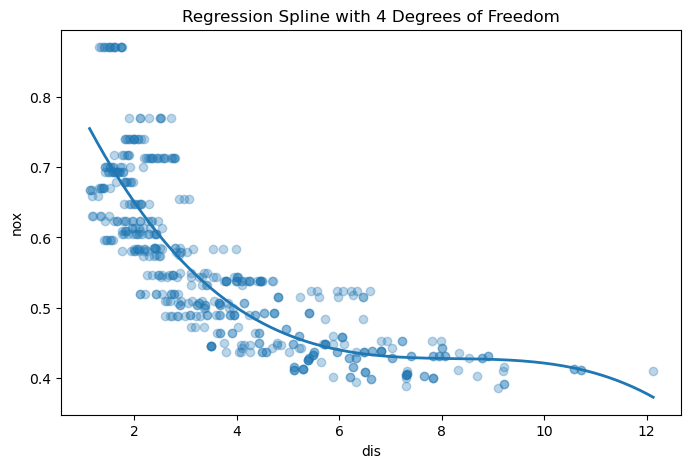

In [6]:
print("=" * 60)
print("REGRESSION SPLINE - 4 DF")
print("=" * 60)

spline4 = SplineTransformer(n_knots=2, degree=3, include_bias=False)
X_spline4 = spline4.fit_transform(X)
spline_model = sm.OLS(y, sm.add_constant(X_spline4)).fit()
print(spline_model.summary())
pred_spline4 = spline_model.predict(sm.add_constant(spline4.transform(grid)))

plt.figure(figsize=(8, 5))
plt.scatter(X, y, alpha=0.3)
plt.plot(grid, pred_spline4, linewidth=2)
plt.xlabel("dis")
plt.ylabel("nox")
plt.title("Regression Spline with 4 Degrees of Freedom")
plt.show()

REGRESSION SPLINES: DIFFERENT DF
 DF      RSS
  4 1.934107
  5 1.929941
  6 1.927396
  7 1.902782
  8 1.873123
  9 1.851981
 10 1.843125


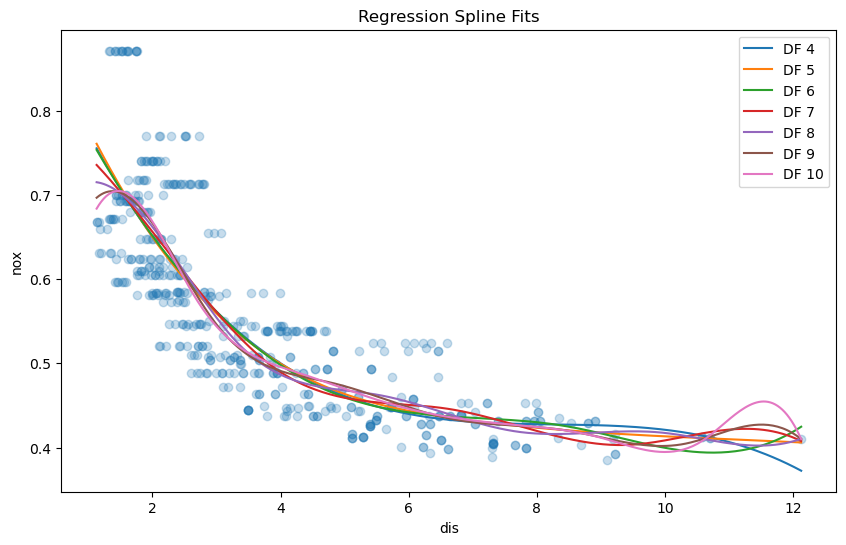

In [7]:
print("=" * 60)
print("REGRESSION SPLINES: DIFFERENT DF")
print("=" * 60)

spline_rss = []
plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.25)

for df in range(4, 11):
    n_knots = max(2, df - 2)
    spline = SplineTransformer(n_knots=n_knots, degree=3, include_bias=False)
    Xs = spline.fit_transform(X)
    model = LinearRegression().fit(Xs, y)
    rss = np.sum((y - model.predict(Xs)) ** 2)
    spline_rss.append([df, rss])
    plt.plot(grid, model.predict(spline.transform(grid)), label=f"DF {df}")

spline_rss_df = pd.DataFrame(spline_rss, columns=["DF", "RSS"])
print(spline_rss_df.to_string(index=False))
plt.xlabel("dis")
plt.ylabel("nox")
plt.title("Regression Spline Fits")
plt.legend()
plt.show()

As the degrees of freedom increase, the training RSS decreases. This is expected because increasing the degrees of freedom makes the spline more flexible and allows it to fit the training observations more closely.

CROSS-VALIDATION FOR SPLINES
 DF   CV_MSE
  4 0.003863
  5 0.003864
  6 0.003863
  7 0.003828
  8 0.003788
  9 0.003746
 10 0.003732

Best spline degrees of freedom = 10


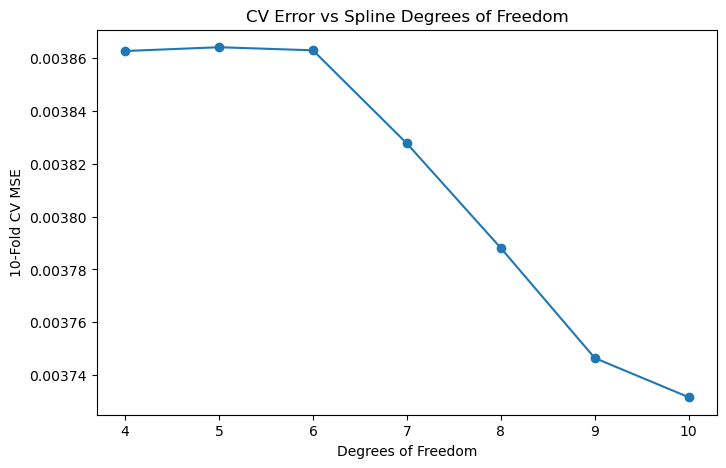

In [8]:
print("=" * 60)
print("CROSS-VALIDATION FOR SPLINES")
print("=" * 60)

spline_cv_results = []
for df in range(4, 11):
    n_knots = max(2, df - 2)
    model = make_pipeline(SplineTransformer(n_knots=n_knots, degree=3, include_bias=False), LinearRegression())
    mse = -cross_val_score(model, X, y, cv=kf, scoring="neg_mean_squared_error").mean()
    spline_cv_results.append([df, mse])

spline_cv_df = pd.DataFrame(spline_cv_results, columns=["DF", "CV_MSE"])
print(spline_cv_df.to_string(index=False))
best_df = int(spline_cv_df.loc[spline_cv_df["CV_MSE"].idxmin(), "DF"])
print(f"\nBest spline degrees of freedom = {best_df}")

plt.figure(figsize=(8, 5))
plt.plot(spline_cv_df["DF"], spline_cv_df["CV_MSE"], marker="o")
plt.xlabel("Degrees of Freedom")
plt.ylabel("10-Fold CV MSE")
plt.title("CV Error vs Spline Degrees of Freedom")
plt.show()

- There is strong evidence of a non-linear relationship between `dis` and `nox`.
- For polynomial regression, cross-validation selected a degree-3 polynomial. Although higher-degree polynomials achieved lower training RSS, they did not improve predictive performance.
- For regression splines, cross-validation selected 10 degrees of freedom. The spline therefore favored a somewhat more flexible model than the polynomial regression.
- Overall, both approaches demonstrate that the relationship between distance to employment centers and nitrogen oxide concentration is substantially non-linear. Cross-validation was important because selecting the model solely based on training RSS would favor unnecessarily complex models.

# Applied Exercise 10 - College Data: Forward Selection and GAM

In [6]:
College = load_data("College").copy()
College = pd.get_dummies(College, drop_first=True, dtype=float)
y = College["Outstate"]
X = College.drop(columns="Outstate")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=1)

print("=" * 60)
print("TRAIN / TEST SPLIT")
print("=" * 60)
print(f"Training observations: {len(X_train)}")
print(f"Test observations: {len(X_test)}")

TRAIN / TEST SPLIT
Training observations: 543
Test observations: 234


In [8]:
print("=" * 60)
print("FORWARD STEPWISE SELECTION")
print("=" * 60)

selected = []
remaining = list(X_train.columns)
current_aic = np.inf

while remaining:
    results = []
    for variable in remaining:
        predictors = selected + [variable]
        model = sm.OLS(y_train, sm.add_constant(X_train[predictors])).fit()
        results.append((model.aic, variable, model))

    best_aic, best_variable, best_model = min(results, key=lambda x: x[0])
    if best_aic < current_aic:
        selected.append(best_variable)
        remaining.remove(best_variable)
        current_aic = best_aic
    else:
        break

print("\nSelected variables:")
print(selected)
print(f"\nNumber of selected variables = {len(selected)}")
print(f"Final AIC = {current_aic:.4f}")
print("\nSelected model:")
print(sm.OLS(y_train, sm.add_constant(X_train[selected])).fit().summary())

FORWARD STEPWISE SELECTION

Selected variables:
['Room.Board', 'perc.alumni', 'Expend', 'Private_Yes', 'PhD', 'Grad.Rate', 'Personal', 'Top25perc', 'Accept', 'Apps', 'Enroll', 'Top10perc', 'S.F.Ratio']

Number of selected variables = 13
Final AIC = 9780.9696

Selected model:
                            OLS Regression Results                            
Dep. Variable:               Outstate   R-squared:                       0.769
Model:                            OLS   Adj. R-squared:                  0.763
Method:                 Least Squares   F-statistic:                     135.3
Date:                Tue, 18 Aug 2026   Prob (F-statistic):          1.20e-158
Time:                        22:18:01   Log-Likelihood:                -4876.5
No. Observations:                 543   AIC:                             9781.
Df Residuals:                     529   BIC:                             9841.
Df Model:                          13                                         
Covariance Ty

The resulting model has an R² of approximately 0.769, indicating that the selected predictors explain about 76.9% of the variation in out-of-state tuition in the training data.

GENERALIZED ADDITIVE MODEL

GAM fitted using:
['Room.Board', 'perc.alumni', 'Expend', 'Private_Yes', 'PhD', 'Grad.Rate', 'Personal', 'Top25perc', 'Accept', 'Apps', 'Enroll', 'Top10perc', 'S.F.Ratio']

GAM training R-squared = 0.8583


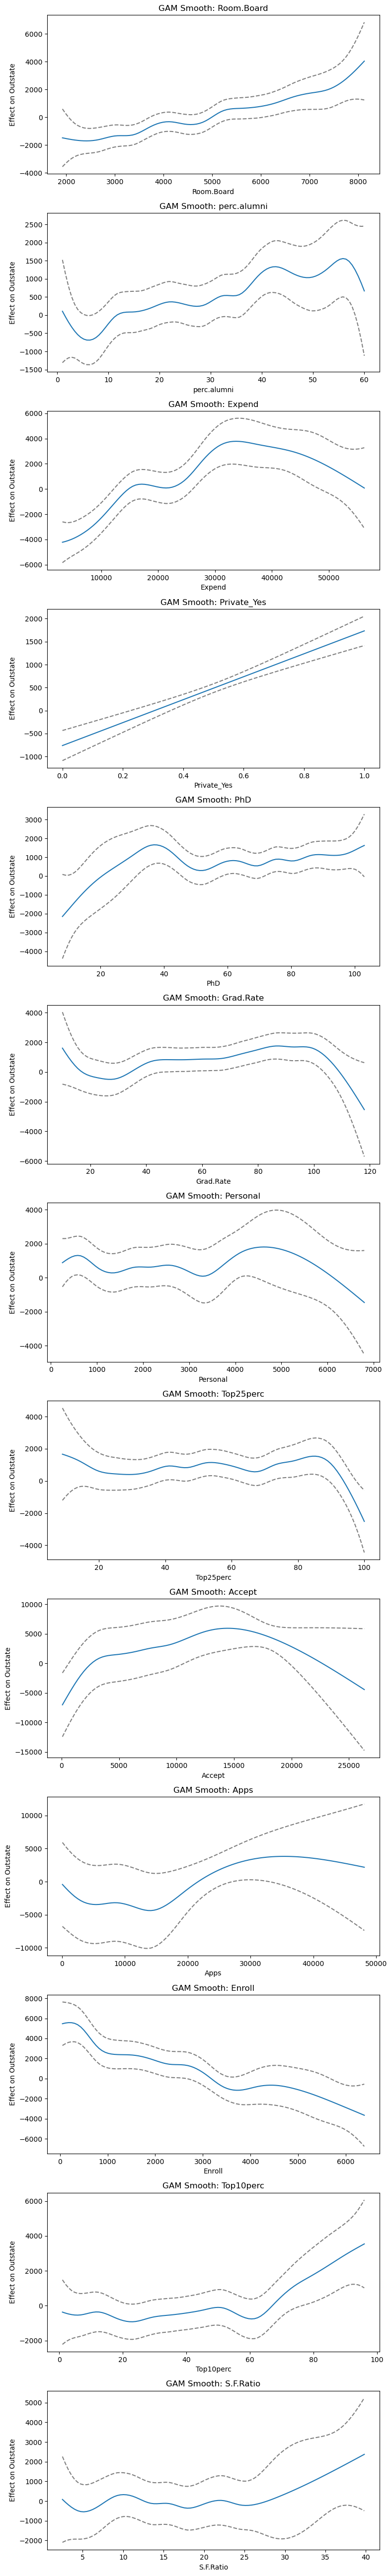

In [9]:
print("=" * 60)
print("GENERALIZED ADDITIVE MODEL")
print("=" * 60)

terms = s(0)
for i in range(1, len(selected)):
    terms += s(i)
gam = LinearGAM(terms).fit(X_train[selected].values, y_train.values)

print("\nGAM fitted using:")
print(selected)
print(f"\nGAM training R-squared = {gam.statistics_['pseudo_r2']['explained_deviance']:.4f}")

fig, axes = plt.subplots(len(selected), 1, figsize=(8, 4 * len(selected)))
if len(selected) == 1:
    axes = [axes]

for i, variable in enumerate(selected):
    XX = gam.generate_X_grid(term=i)
    axes[i].plot(XX[:, i], gam.partial_dependence(term=i, X=XX))
    axes[i].plot(XX[:, i], gam.partial_dependence(term=i, X=XX, width=.95)[1], c="gray", ls="--")
    axes[i].set_xlabel(variable)
    axes[i].set_ylabel("Effect on Outstate")
    axes[i].set_title(f"GAM Smooth: {variable}")

plt.tight_layout()
plt.show()

The GAM achieved a training R² of approximately 0.8583, compared with 0.769 for the linear model. This suggests that allowing flexible non-linear relationships between the predictors and out-of-state tuition provides a substantially better fit to the training data.

The GAM plots can be used to visualize how each predictor is associated with out-of-state tuition while holding the other terms in the model approximately constant.

TEST SET PERFORMANCE
Test MSE  = 3666004.6400
Test RMSE = 1914.6813


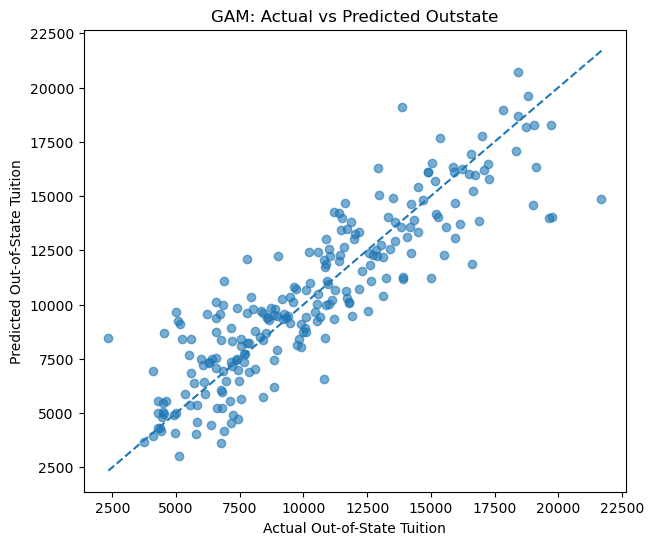

In [10]:
print("=" * 60)
print("TEST SET PERFORMANCE")
print("=" * 60)

y_pred = gam.predict(X_test[selected].values)
test_mse = mean_squared_error(y_test, y_pred)
test_rmse = np.sqrt(test_mse)
print(f"Test MSE  = {test_mse:.4f}")
print(f"Test RMSE = {test_rmse:.4f}")

plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle="--")
plt.xlabel("Actual Out-of-State Tuition")
plt.ylabel("Predicted Out-of-State Tuition")
plt.title("GAM: Actual vs Predicted Outstate")
plt.show()

The RMSE indicates that the model's predictions differ from the actual out-of-state tuition values by roughly $1,915 on average in terms of the typical prediction error magnitude.

Although the GAM had a substantially higher training R² than the linear model, its test-set performance is the appropriate measure for assessing its predictive ability on unseen observations.

In [12]:
print("=" * 60)
print("EVIDENCE OF NON-LINEAR RELATIONSHIPS")
print("=" * 60)

for i, variable in enumerate(selected):
    p_value = gam.statistics_["p_values"][i + 1]
    print(f"{variable}: p-value = {p_value:.6f}")

EVIDENCE OF NON-LINEAR RELATIONSHIPS
Room.Board: p-value = 0.033896
perc.alumni: p-value = 0.000000
Expend: p-value = 0.000000
Private_Yes: p-value = 0.102976
PhD: p-value = 0.009498
Grad.Rate: p-value = 0.028073
Personal: p-value = 0.115634
Top25perc: p-value = 0.000000
Accept: p-value = 0.000620
Apps: p-value = 0.000002
Enroll: p-value = 0.558401
Top10perc: p-value = 0.778246
S.F.Ratio: p-value = 0.000000


There was not significant evidence of non-linearity for `Private_Yes`, `Personal`, `Enroll`, or `Top10perc`.

Overall, the results suggest that several of the quantitative predictors have relationships with out-of-state tuition that are not adequately described by a simple straight line. This helps explain why the GAM achieved a higher training R² than the linear model.

# Applied Exercise 11 - Backfitting: Implementing multiple regression using simple regression

In [2]:
rng = np.random.default_rng(1)
n = 100
X1 = rng.normal(size=n)
X2 = rng.normal(size=n)
Y = 3 + 2*X1 - 1.5*X2 + rng.normal(size=n)

def simple_reg(outcome, feature):
    model = sm.OLS(outcome, sm.add_constant(feature)).fit()
    return model.params[0], model.params[1]

beta1 = 0.0
beta0 = 0.0
beta2 = 0.0
# Store coefficient estimates at every iteration
history = []

for i in range(1000):
    beta0, beta2 = simple_reg(Y - beta1*X1, X2)
    beta0, beta1 = simple_reg(Y - beta2*X2, X1)
    history.append([i + 1, beta0, beta1, beta2])

history = pd.DataFrame(history, columns=["Iteration", "Beta0", "Beta1", "Beta2"])

print("=" * 60)
print("BACKFITTING RESULTS")
print("=" * 60)
print(history.tail())

print("\nFinal backfitting estimates:")
print(f"Beta0 = {beta0:.4f}")
print(f"Beta1 = {beta1:.4f}")
print(f"Beta2 = {beta2:.4f}")

BACKFITTING RESULTS
     Iteration     Beta0     Beta1     Beta2
995        996  2.836997  1.986775 -1.514153
996        997  2.836997  1.986775 -1.514153
997        998  2.836997  1.986775 -1.514153
998        999  2.836997  1.986775 -1.514153
999       1000  2.836997  1.986775 -1.514153

Final backfitting estimates:
Beta0 = 2.8370
Beta1 = 1.9868
Beta2 = -1.5142


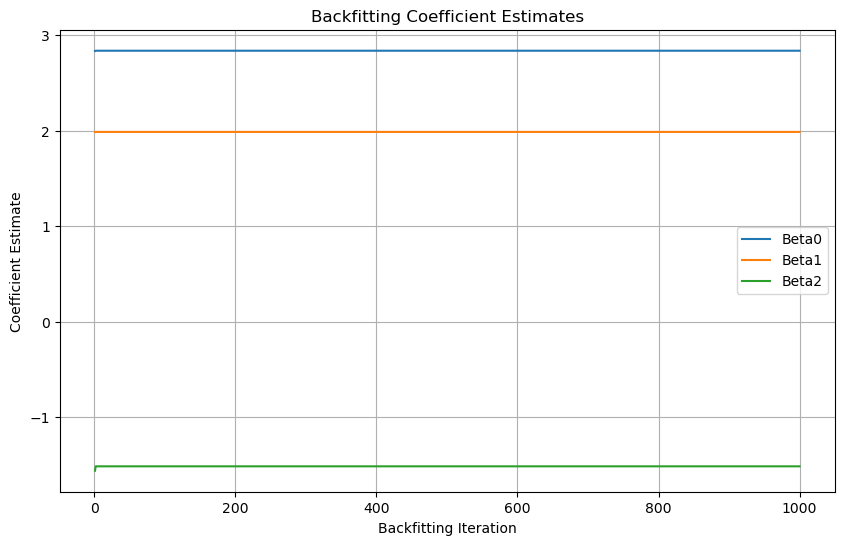

In [3]:
plt.figure(figsize=(10, 6))
plt.plot(history["Iteration"], history["Beta0"], label="Beta0")
plt.plot(history["Iteration"], history["Beta1"], label="Beta1")
plt.plot(history["Iteration"], history["Beta2"], label="Beta2")
plt.xlabel("Backfitting Iteration")
plt.ylabel("Coefficient Estimate")
plt.title("Backfitting Coefficient Estimates")
plt.legend()
plt.grid(True)
plt.show()


MULTIPLE LINEAR REGRESSION
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.863
Model:                            OLS   Adj. R-squared:                  0.860
Method:                 Least Squares   F-statistic:                     305.8
Date:                Mon, 24 Aug 2026   Prob (F-statistic):           1.29e-42
Time:                        18:48:32   Log-Likelihood:                -132.78
No. Observations:                 100   AIC:                             271.6
Df Residuals:                      97   BIC:                             279.4
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.8370   

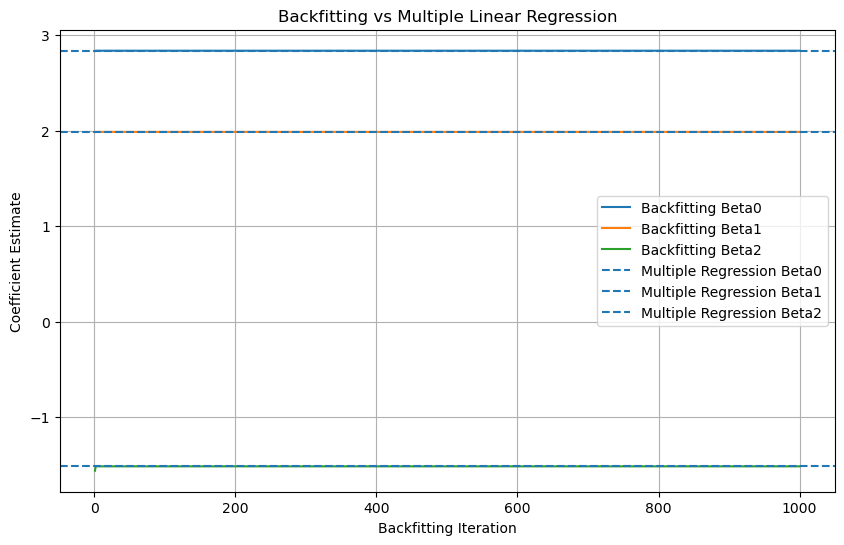

In [4]:
X_multiple = sm.add_constant(np.column_stack((X1, X2)))
multiple_model = sm.OLS(Y, X_multiple).fit()
multiple_coef = multiple_model.params

print("\n" + "=" * 60)
print("MULTIPLE LINEAR REGRESSION")
print("=" * 60)
print(multiple_model.summary())

print("\nMultiple regression estimates:")
print(f"Beta0 = {multiple_coef[0]:.4f}")
print(f"Beta1 = {multiple_coef[1]:.4f}")
print(f"Beta2 = {multiple_coef[2]:.4f}")

# Overlay multiple regression coefficient estimates
plt.figure(figsize=(10, 6))
plt.plot(history["Iteration"], history["Beta0"], label="Backfitting Beta0")
plt.plot(history["Iteration"], history["Beta1"], label="Backfitting Beta1")
plt.plot(history["Iteration"], history["Beta2"], label="Backfitting Beta2")

plt.axhline(multiple_coef[0], linestyle="--", label="Multiple Regression Beta0")
plt.axhline(multiple_coef[1], linestyle="--", label="Multiple Regression Beta1")
plt.axhline(multiple_coef[2], linestyle="--", label="Multiple Regression Beta2")

plt.xlabel("Backfitting Iteration")
plt.ylabel("Coefficient Estimate")
plt.title("Backfitting vs Multiple Linear Regression")
plt.legend()
plt.grid(True)
plt.show()

In [5]:
target = multiple_coef
errors = np.max(np.abs(history[["Beta0", "Beta1", "Beta2"]].values - target), axis=1)
good_iteration = np.where(errors < 1e-4)[0][0] + 1

print("\n" + "=" * 60)
print("CONVERGENCE")
print("=" * 60)
print(f"Iterations required for approximation within 1e-4 = {good_iteration}")


CONVERGENCE
Iterations required for approximation within 1e-4 = 2


- Backfitting = repeatedly use simple regression to update one predictor's effect while temporarily treating the other predictors' effects as fixed, until the estimates converge to the multiple-regression solution.
- The coefficient estimates obtained through backfitting converge to the coefficient estimates obtained from ordinary multiple linear regression.
This demonstrates that repeatedly updating one coefficient at a time can recover the multiple regression solution.
- The coefficient estimates converge rapidly to the multiple regression estimates. Only a relatively small number of backfitting iterations are
required to obtain a very close approximation, despite performing 1,000 iterations in total.